Tarefa de classificação de grãos utilizando aprendizado profundo

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('beans_train.csv')
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,38465.705594,737.090445,273.111968,179.201525,1.523333,0.753998,38999.014066,220.991553,0.813252,0.988670,0.888416,0.809359,0.007117,0.001879,0.655710,0.996874,SIRA
1,70247.179155,1019.740591,376.308440,238.192942,1.582115,0.773556,71562.831696,299.139162,0.707757,0.985750,0.850248,0.794947,0.005351,0.001324,0.632118,0.998320,BARBUNYA
2,74212.949558,1049.756998,414.858346,229.655950,1.810139,0.834413,75004.806409,306.719019,0.776048,0.987679,0.844313,0.739884,0.005597,0.001039,0.548725,0.991096,CALI
3,31233.029736,671.584675,257.751304,154.448259,1.670969,0.800540,31682.423625,198.813755,0.718182,0.988299,0.870828,0.773574,0.008257,0.001822,0.598230,0.996528,DERMASON
4,48189.750788,826.752018,313.328739,196.497443,1.604009,0.781591,48840.530648,247.963648,0.796755,0.988498,0.887039,0.788613,0.006525,0.001556,0.622442,0.995508,SIRA


Como queremos treinar um modelo que seja capaz de classificar de forma correta as classes de grãos, vamos retirar a coluna de classe dos grãos do dataset de treino e utilizá-la como sáida esperada. Devemos també tranformar a coluna "Class" de string para numérico, já que trabalharemos com redes neurais.

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

encoder = LabelEncoder()
y = encoder.fit_transform(y)

Agora que as saídas já estão codificadas, podemos realizar a divisão do conjunto de dado. Porém, essa divisão deve ser feita de forma estratificada, pois já foi avisado que o dataset contém classes desbalanceadas. Além disse, usaremos o StandardScaler para normalizar a escala dos atributos.

In [27]:
X_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Segunda divisão: Pega os 80% restantes (temp) e separa 25% para Validação (que equivale a 20% do total). 
# Os outros 75% formam o Treino (60% do total).
x_train, x_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 3. Normalização: o Scaler aprende APENAS com o Treino para evitar vazamento de dados
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)    # Aplica na Validação
x_test = scaler.transform(x_test)

Esses gráficos são apenas para auxiliar a vizualização do desbalanceamento no dataset

C:\Users\clari\AppData\Local\Temp\ipykernel_20416\1557534847.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Class', order=order_class, palette='viridis')


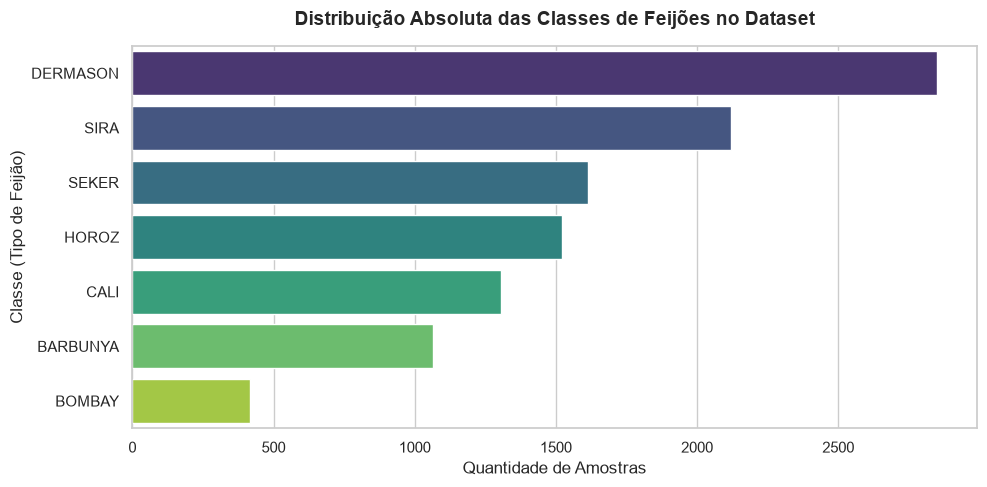

C:\Users\clari\AppData\Local\Temp\ipykernel_20416\1557534847.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Area', y='Class', order=order_boxplot, palette='plasma')


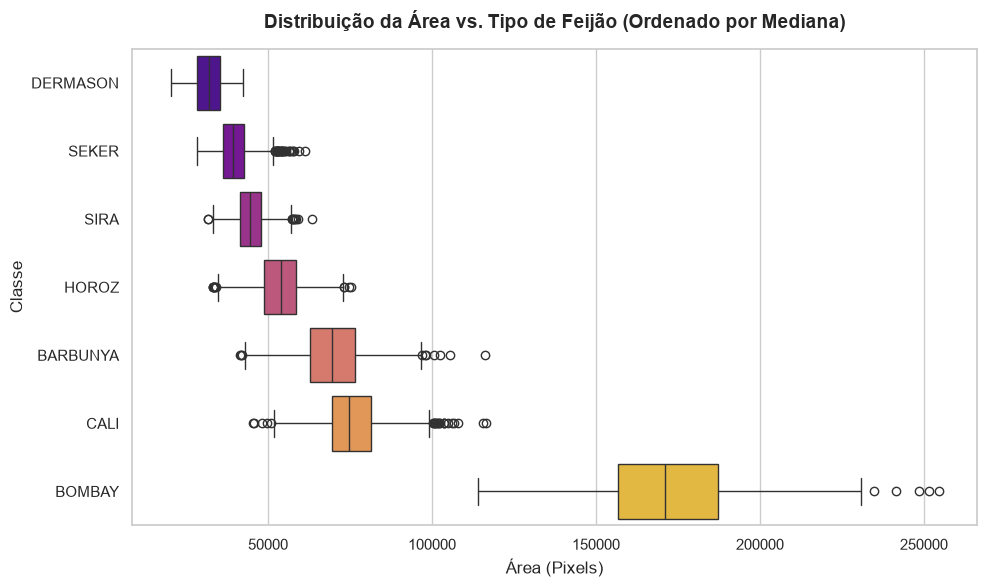

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual semelhante à sua
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Gráfico de Distribuição das Classes (Mostra o Desbalanceamento)
plt.figure(figsize=(10, 5))
# Contamos os valores da coluna 'Class' e ordenamos
order_class = df['Class'].value_counts().index
sns.countplot(data=df, y='Class', order=order_class, palette='viridis')

plt.title('Distribuição Absoluta das Classes de Feijões no Dataset', fontweight='bold', pad=15)
plt.xlabel('Quantidade de Amostras')
plt.ylabel('Classe (Tipo de Feijão)')
plt.tight_layout()
plt.show()

# 2. Boxplot: Atributo Geométrico vs. Classe (Substituindo a 'Idade')
# Vamos usar o atributo 'Area' (ou 'Perimeter') para ver a diferença de tamanho entre as classes
plt.figure(figsize=(10, 6))
# Ordenar as classes pela mediana da Área
order_boxplot = df.groupby('Class')['Area'].median().sort_values().index
sns.boxplot(data=df, x='Area', y='Class', order=order_boxplot, palette='plasma')

plt.title('Distribuição da Área vs. Tipo de Feijão (Ordenado por Mediana)', fontweight='bold', pad=15)
plt.xlabel('Área (Pixels)')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

In [29]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# 1. Convertendo as entradas para tensores float32 (agora são três conjuntos)
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

# 2. Convertendo as saídas para tensores long
y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.long)

# 3. Criando os Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 4. Criando os DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [22]:
import torch.nn as nn

class MLPBeanClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLPBeanClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128), # Estabilidade
            nn.ReLU(),
            nn.Dropout(0.3),     # Regularização
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Instanciando o modelo
input_dim = x_train.shape[1] 
num_classes = 7              

model = MLPBeanClassifier(input_dim, num_classes)

Para lidar com o severo desbalanceamento das classes durante o treinamento, calculamos os pesos de cada classe utilizando o compute_class_weight configurado como balanced. Estes pesos foram acoplados à função de custo CrossEntropyLoss, garantindo que o modelo seja penalizado de forma mais rigorosa ao errar predições das classes minoritárias, evitando assim um viés indesejado em direção às classes com maior volume de amostras.

In [ ]:

from sklearn.utils.class_weight import compute_class_weight

# 1. Calcula os pesos usando o y_train gerado no train_test_split
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)


# 2. Converte o array do NumPy para um Tensor do PyTorch (tipo float32)
pesos_tensor = torch.tensor(pesos, dtype=torch.float32)

# 3. Define a Função de Perda (Loss) passando os pesos para ela
# O PyTorch cuidará de aplicar o peso correto para cada classe durante o cálculo do erro
criterion = nn.CrossEntropyLoss(weight=pesos_tensor)

# Definindo o Otimizador (Adam é o padrão mais eficiente)
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
epochs = 100

# Equivalente ao "history" do Keras
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # --- TREINO ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
        # Cálculo de acertos no treino
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_losses.append(running_loss / len(train_loader.dataset))
    train_accs.append(100 * correct_train / total_train)
    
    # --- VALIDAÇÃO ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        # AQUI: Usando val_loader em vez de test_loader
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            
            # Cálculo de acertos na validação
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # AQUI: Dividindo pelo tamanho do val_loader
    val_losses.append(val_loss / len(val_loader.dataset))
    val_accs.append(100 * correct_val / total_val)
    
    # Imprime o progresso (como o Keras faz por padrão)
    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1:03d}/{epochs} | '
              f'Loss Treino: {train_losses[-1]:.4f} | Acc Treino: {train_accs[-1]:.2f}% | '
              f'Loss Val: {val_losses[-1]:.4f} | Acc Val: {val_accs[-1]:.2f}%')

Época 010/100 | Loss Treino: 0.1872 | Acc Treino: 92.33% | Loss Val: 0.1514 | Acc Val: 92.98%
Época 020/100 | Loss Treino: 0.1985 | Acc Treino: 91.84% | Loss Val: 0.1607 | Acc Val: 92.93%
Época 030/100 | Loss Treino: 0.1781 | Acc Treino: 92.35% | Loss Val: 0.1609 | Acc Val: 92.79%
Época 040/100 | Loss Treino: 0.1791 | Acc Treino: 92.36% | Loss Val: 0.1596 | Acc Val: 92.88%
Época 050/100 | Loss Treino: 0.1800 | Acc Treino: 92.13% | Loss Val: 0.1553 | Acc Val: 92.88%
Época 060/100 | Loss Treino: 0.1738 | Acc Treino: 92.65% | Loss Val: 0.1625 | Acc Val: 92.98%
Época 070/100 | Loss Treino: 0.1823 | Acc Treino: 91.96% | Loss Val: 0.1632 | Acc Val: 92.75%
Época 080/100 | Loss Treino: 0.1814 | Acc Treino: 92.41% | Loss Val: 0.1635 | Acc Val: 92.98%
Época 090/100 | Loss Treino: 0.1748 | Acc Treino: 92.53% | Loss Val: 0.1660 | Acc Val: 92.93%
Época 100/100 | Loss Treino: 0.1787 | Acc Treino: 92.05% | Loss Val: 0.1601 | Acc Val: 92.79%


--- Relatório de Classificação (Dados de Teste) ---
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.92      0.94       213
      BOMBAY       1.00      1.00      1.00        83
        CALI       0.91      0.97      0.94       261
    DERMASON       0.93      0.90      0.92       570
       HOROZ       0.95      0.94      0.95       304
       SEKER       0.96      0.96      0.96       323
        SIRA       0.86      0.88      0.87       424

    accuracy                           0.93      2178
   macro avg       0.94      0.94      0.94      2178
weighted avg       0.93      0.93      0.93      2178



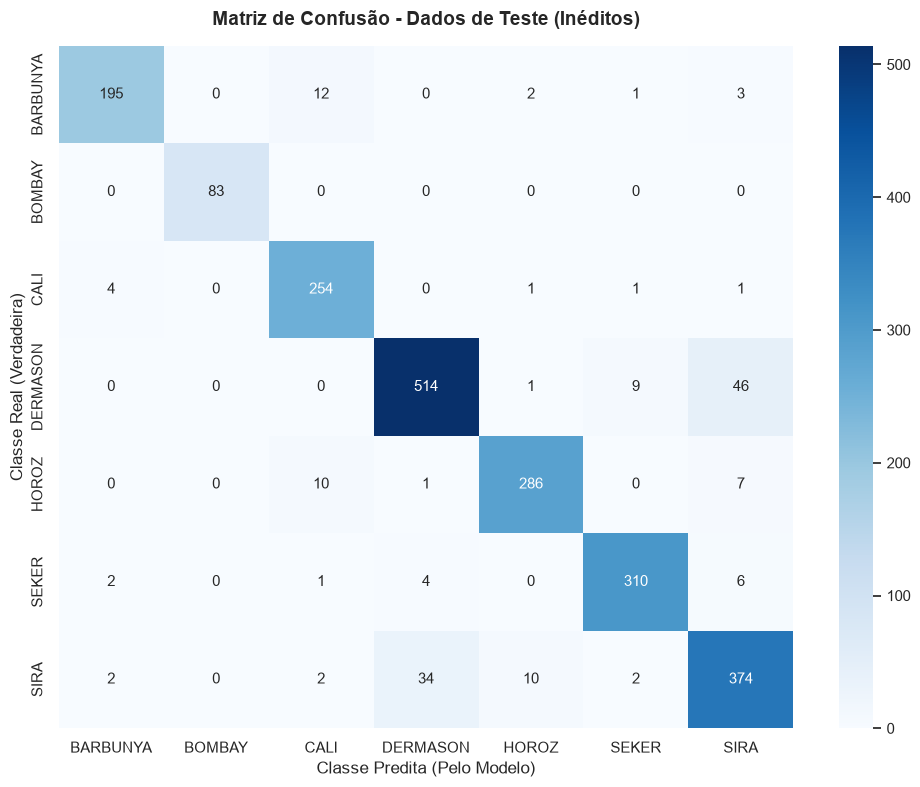

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Travar o modelo em modo de avaliação (desliga o Dropout)
model.eval()

y_true = []
y_pred = []

# 2. Iterar EXCLUSIVAMENTE sobre o conjunto de teste inédito
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        
        # Extrai a predição com a maior probabilidade
        _, predicted = torch.max(outputs, 1)
        
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())

# 3. Recuperar os nomes originais das classes criados pelo LabelEncoder
nomes_classes = encoder.classes_

# 4. Imprimir o Relatório de Classificação Final
print("--- Relatório de Classificação (Dados de Teste) ---")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

# 5. Gerar a Matriz de Confusão Visual
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomes_classes, 
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão - Dados de Teste (Inéditos)', fontweight='bold', pad=15)
plt.ylabel('Classe Real (Verdadeira)')
plt.xlabel('Classe Predita (Pelo Modelo)')
plt.tight_layout()
plt.show()

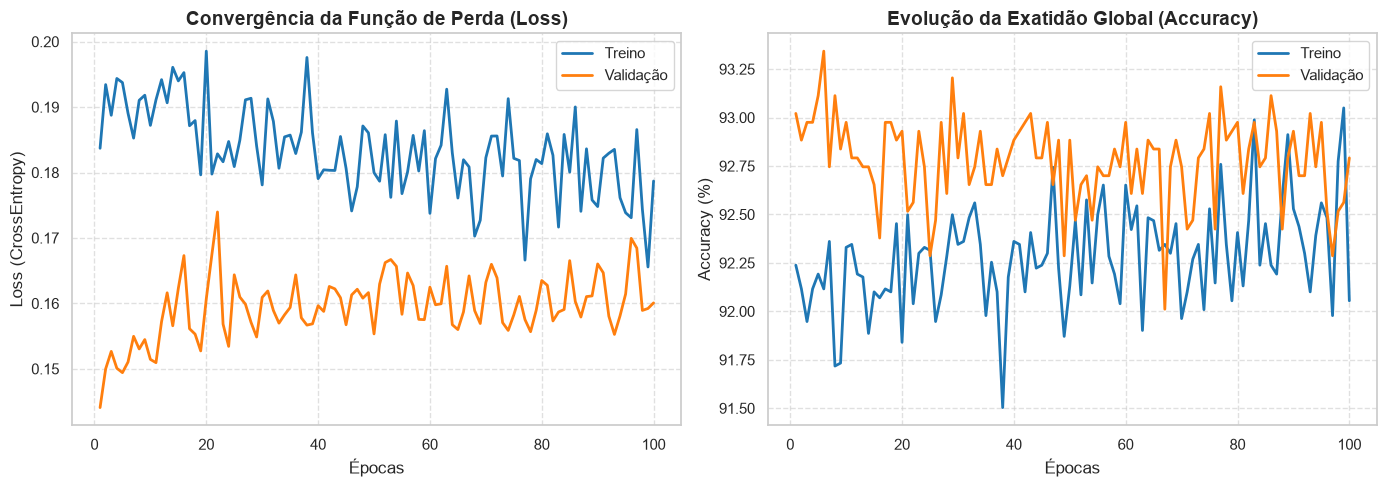

In [31]:
vetor_epocas = np.arange(1, epochs + 1)

plt.figure(figsize=(14, 5))

# Gráfico 1: Curva de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(vetor_epocas, train_losses, label='Treino', color='#1f77b4', linewidth=2)
plt.plot(vetor_epocas, val_losses, label='Validação', color='#ff7f0e', linewidth=2)
plt.title('Convergência da Função de Perda (Loss)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Curva de Exatidão (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(vetor_epocas, train_accs, label='Treino', color='#1f77b4', linewidth=2)
plt.plot(vetor_epocas, val_accs, label='Validação', color='#ff7f0e', linewidth=2)
plt.title('Evolução da Exatidão Global (Accuracy)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

--- Relatório de Classificação (Dados de Teste) ---
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.92      0.94       213
      BOMBAY       1.00      1.00      1.00        83
        CALI       0.91      0.97      0.94       261
    DERMASON       0.93      0.90      0.92       570
       HOROZ       0.95      0.94      0.95       304
       SEKER       0.96      0.96      0.96       323
        SIRA       0.86      0.88      0.87       424

    accuracy                           0.93      2178
   macro avg       0.94      0.94      0.94      2178
weighted avg       0.93      0.93      0.93      2178



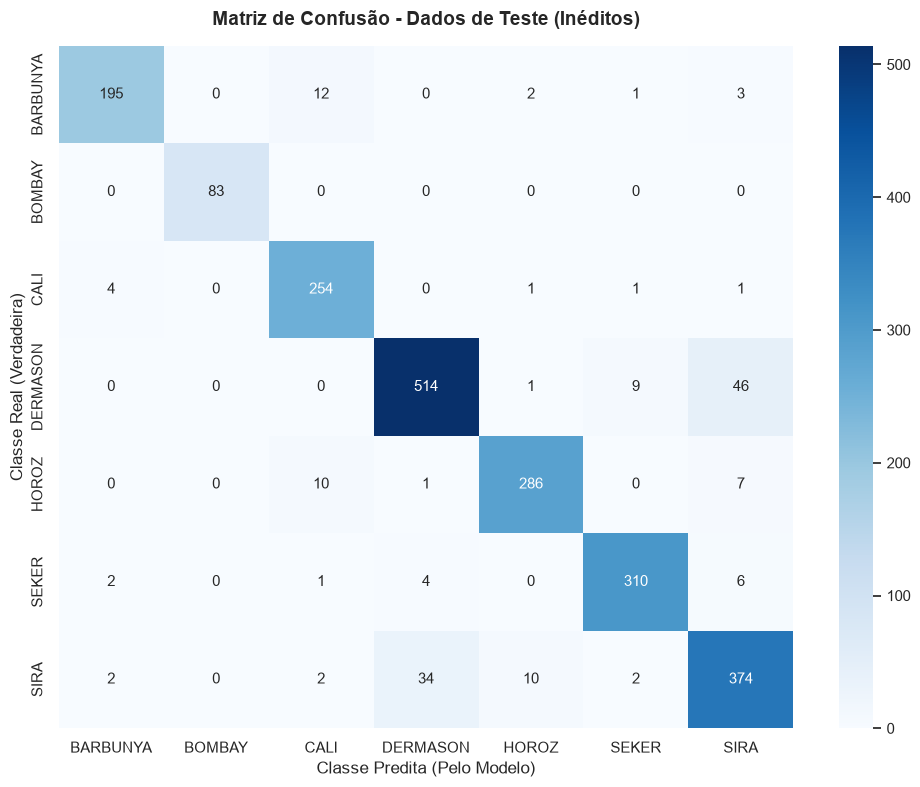

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Travar o modelo em modo de avaliação (desliga o Dropout)
model.eval()

y_true = []
y_pred = []

# 2. Iterar EXCLUSIVAMENTE sobre o conjunto de teste inédito
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        
        # Extrai a predição com a maior probabilidade
        _, predicted = torch.max(outputs, 1)
        
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())

# 3. Recuperar os nomes originais das classes criados pelo LabelEncoder
nomes_classes = encoder.classes_

# 4. Imprimir o Relatório de Classificação Final
print("--- Relatório de Classificação (Dados de Teste) ---")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

# 5. Gerar a Matriz de Confusão Visual
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomes_classes, 
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão - Dados de Teste (Inéditos)', fontweight='bold', pad=15)
plt.ylabel('Classe Real (Verdadeira)')
plt.xlabel('Classe Predita (Pelo Modelo)')
plt.tight_layout()
plt.show()